In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('MBTA_Bus_Ridership_Fall_2019.csv', low_memory=False)
df

,season,route_id,route_variant,direction_id,trip_start_time,day_type_id,day_type_name,stop_name,stop_id,stop_sequence,boardings,alightings,load_,sample_size,ObjectId
0,Fall 2019,1,1-0-0,0,04:37:00,day_type_01,weekday,MASSACHUSETTS AVE @ TROWBRIDG,108,23,0.0,1.1,4.6,65,2588430
1,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ TROWBRIDG,108,23,0.4,0.0,3.4,64,2588432
2,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ BOW ST,109,24,0.0,0.0,3.4,64,2588466
3,Fall 2019,1,1-0-0,0,04:37:00,day_type_01,weekday,MASSACHUSETTS AVE @ BOW ST,109,24,0.0,0.4,4.2,65,2588471
4,Fall 2019,1,1-0-0,0,04:52:00,day_type_01,weekday,MASSACHUSETTS AVE @ HOLYOKE S,110,25,0.0,3.0,0.4,64,2588472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863035,Fall 2019,99,99-0-1,1,24:31:00,day_type_01,weekday,MAIN ST @ WEST ST,5404,36,0.0,0.2,4.6,25,3451978
863036,Fall 2019,99,99-0-1,1,24:31:00,day_type_01,weekday,MAIN ST @ BROWN TERR,5447,24,0.0,0.2,6.2,25,3451979
863037,Fall 2019,99,99-0-1,1,24:31:00,day_type_01,weekday,MAIN ST @ WIGGLESWORTH ST,5449,26,0.0,0.6,5.6,25,3451980
863038,Fall 2019,99,99-0-1,1,24:31:00,day_type_01,weekday,SANTILLI CIRCLE,5561,37,0.0,0.0,4.6,25,3451981


In [6]:
def clean_ridership(filename):
    
    # Loads file
    file = pd.read_csv(filename, low_memory=False)

    file = file.dropna()
    
    file['total_boardings'] = file['boardings'] * file['sample_size']
    file['total_alightings'] = file['alightings'] * file['sample_size']

    return file.drop(['boardings', 'alightings', 'sample_size'], axis=1)

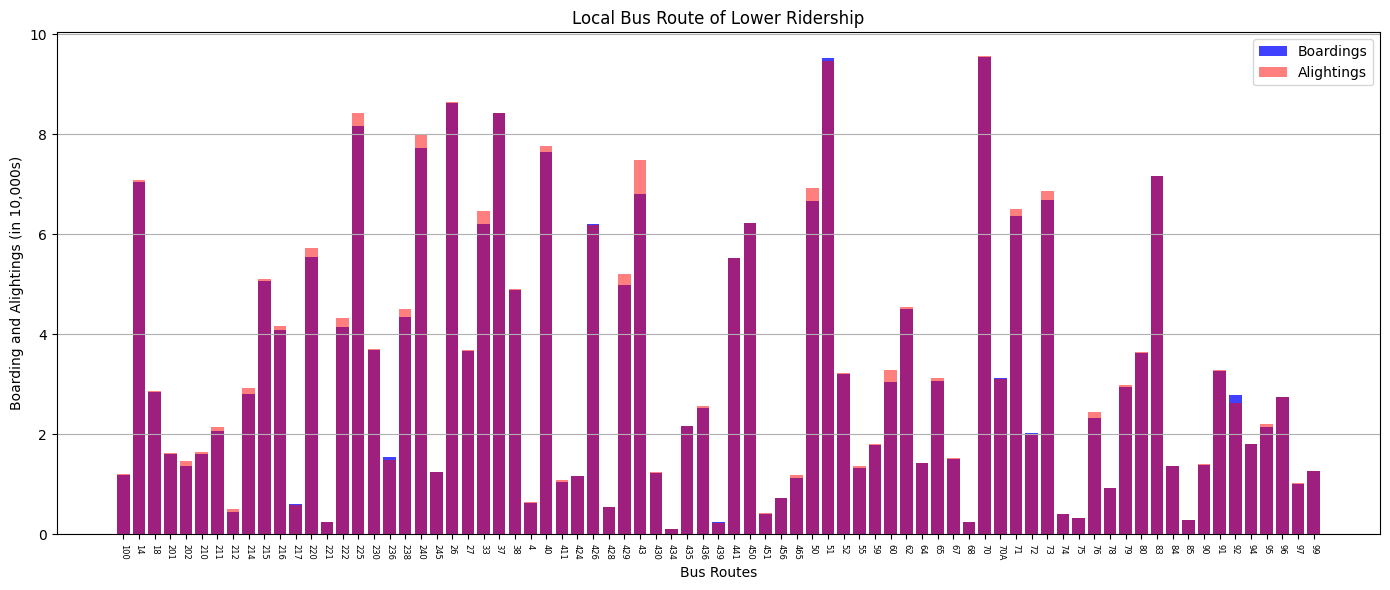

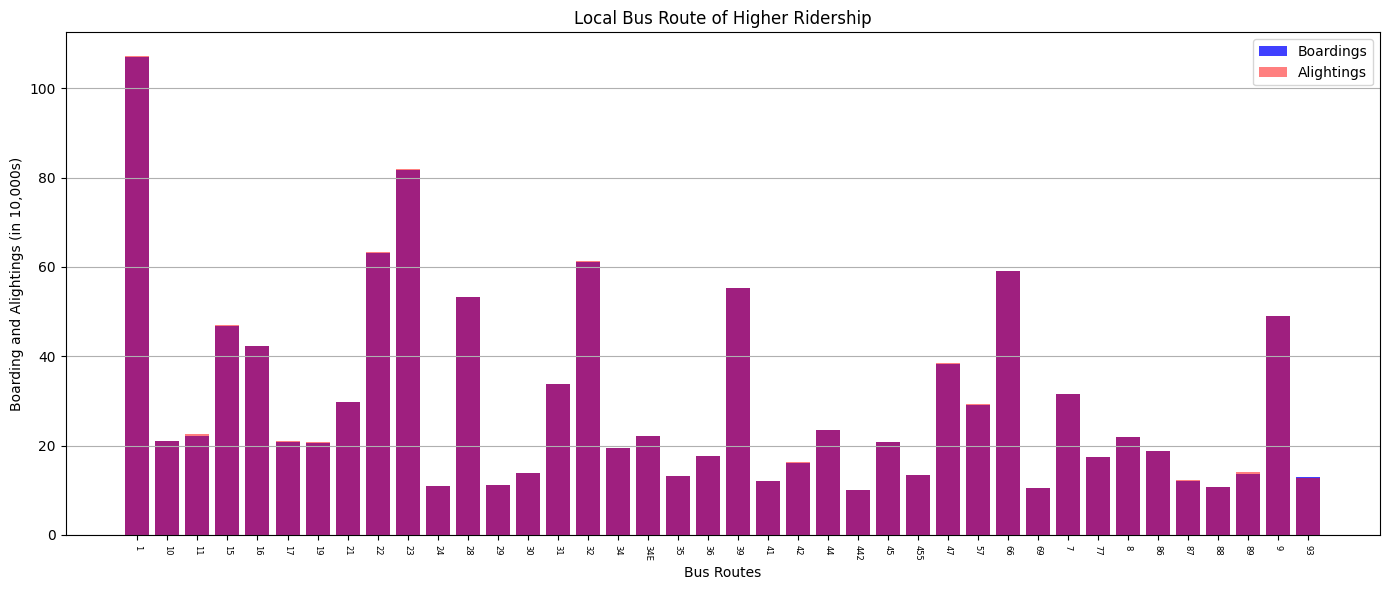

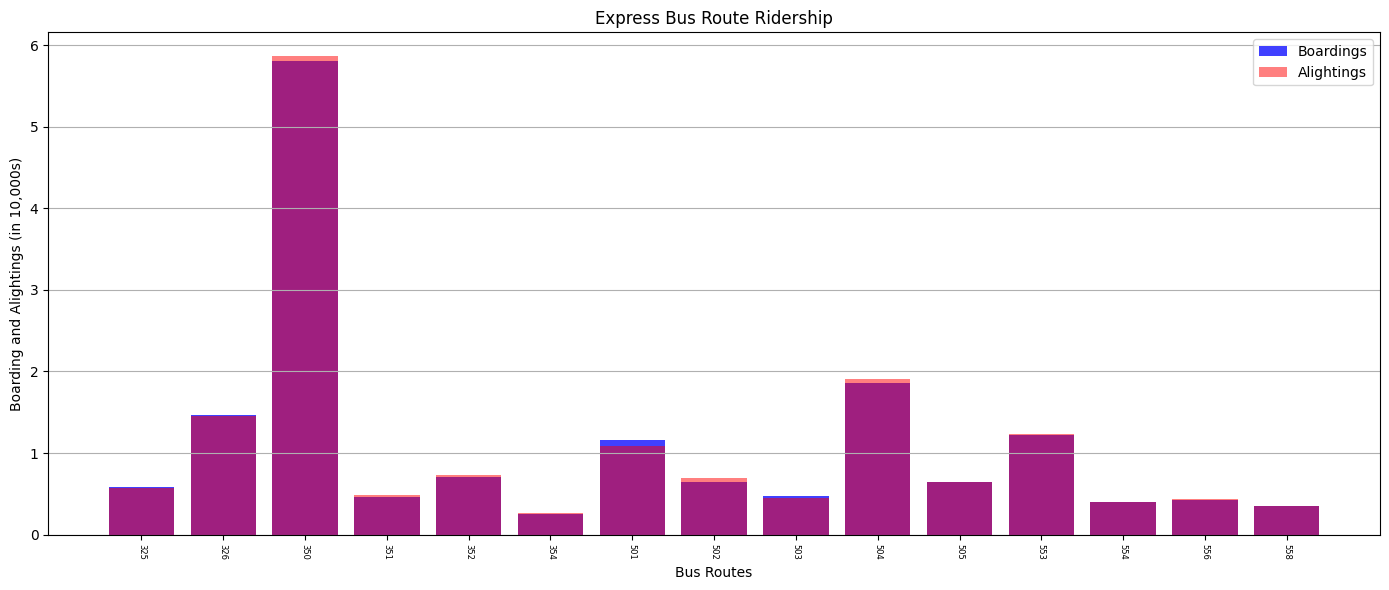

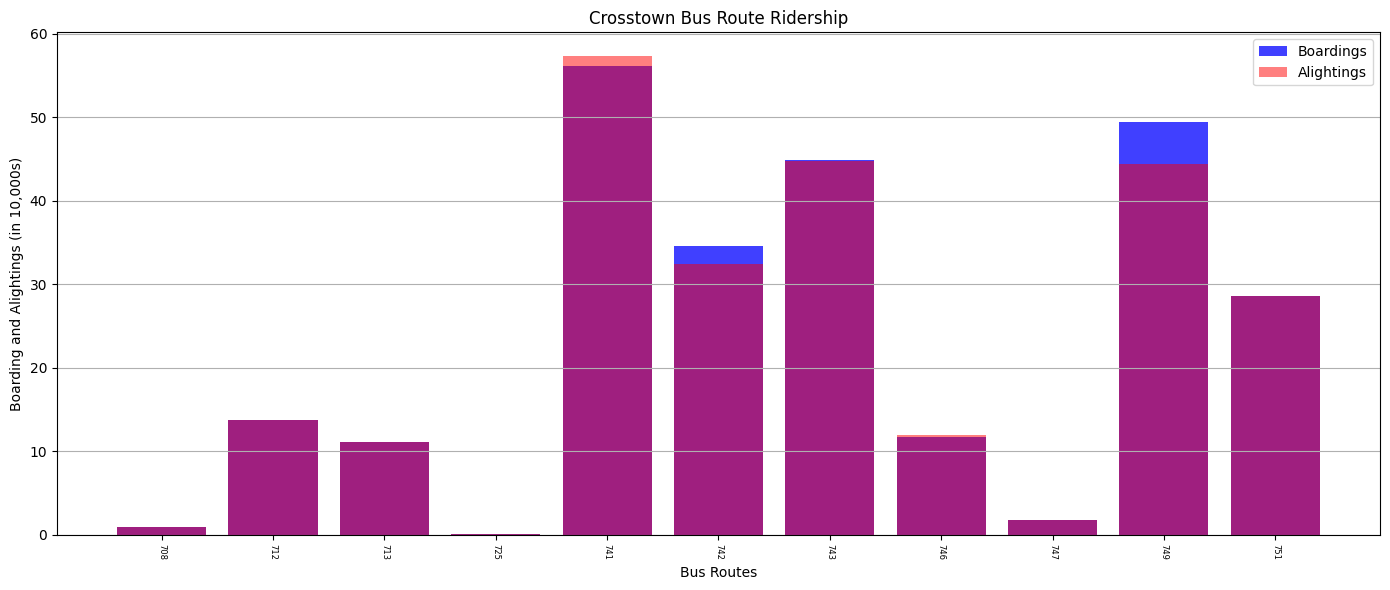

In [45]:
# Loads file
df = clean_ridership('MBTA_Bus_Ridership_Fall_2019.csv')

routes = np.unique(df['route_id'])

local_routes = []
express_routes = []
crosstown = []
limited_express_400s = [426, 428, 441, 442, 450, 455, 456]

for route in routes:
    # Convert to int if possible, otherwise keep it as a string for cases like '34E' or '70A'
    try:
        route_num = int(route)
    except ValueError:
        route_num = route  # Keep as is if not convertible

    if isinstance(route_num, int):
        if 1 <= route_num <= 100:
            local_routes.append(route)
        elif 200 <= route_num <= 299:
            local_routes.append(route)  # 200s considered local
        elif 300 <= route_num <= 399:
            express_routes.append(route)  # 300s considered express
        elif 400 <= route_num <= 499:
            if route in limited_express_400s:
                express_routes.append(route)  # Specific 400s as express
            else:
                local_routes.append(route) # Rest considered local
        elif 500 <= route_num <= 599:
            express_routes.append(route)
        elif 700 <= route_num <= 799:
            crosstown.append(route)
    else:
        # Include any other routes that are not numerical number
        if isinstance(route, str):
            local_routes.append(route)
            
local = df[df['route_id'].isin(local_routes)]
express = df[df['route_id'].isin(express_routes)]
ct = df[df['route_id'].isin(crosstown)]

#Calculates boardings and alightings by bus routes
local_ridership_by_stop = local.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
local_ridership_by_stop["difference"] = local_ridership_by_stop['total_boardings'] - local_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
express_ridership_by_stop = express.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
express_ridership_by_stop["difference"] = express_ridership_by_stop['total_boardings'] - express_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
ct_ridership_by_stop = ct.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
ct_ridership_by_stop["difference"] = ct_ridership_by_stop['total_boardings'] - ct_ridership_by_stop['total_alightings']

lower_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] <= 100000) | 
    (local_ridership_by_stop['total_alightings'] <= 100000)
]

higher_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] > 100000) & 
    (local_ridership_by_stop['total_alightings'] > 100000)
]

# Lower Local Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(lower_local_low_ridership.index.astype(str), lower_local_low_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(lower_local_low_ridership.index.astype(str), lower_local_low_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route of Lower Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')  # Grid lines only on the y-axis
plt.ylim(0, None)
plt.show()

# Higher Local Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(higher_local_low_ridership.index.astype(str), higher_local_low_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(higher_local_low_ridership.index.astype(str), higher_local_low_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route of Higher Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')  # Grid lines only on the y-axis
plt.ylim(0, None)
plt.show()

# Express Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(express_ridership_by_stop.index.astype(str), express_ridership_by_stop['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(express_ridership_by_stop.index.astype(str), express_ridership_by_stop['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Express Bus Route Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Crosstown Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(ct_ridership_by_stop.index.astype(str), ct_ridership_by_stop['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(ct_ridership_by_stop.index.astype(str), ct_ridership_by_stop['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Crosstown Bus Route Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

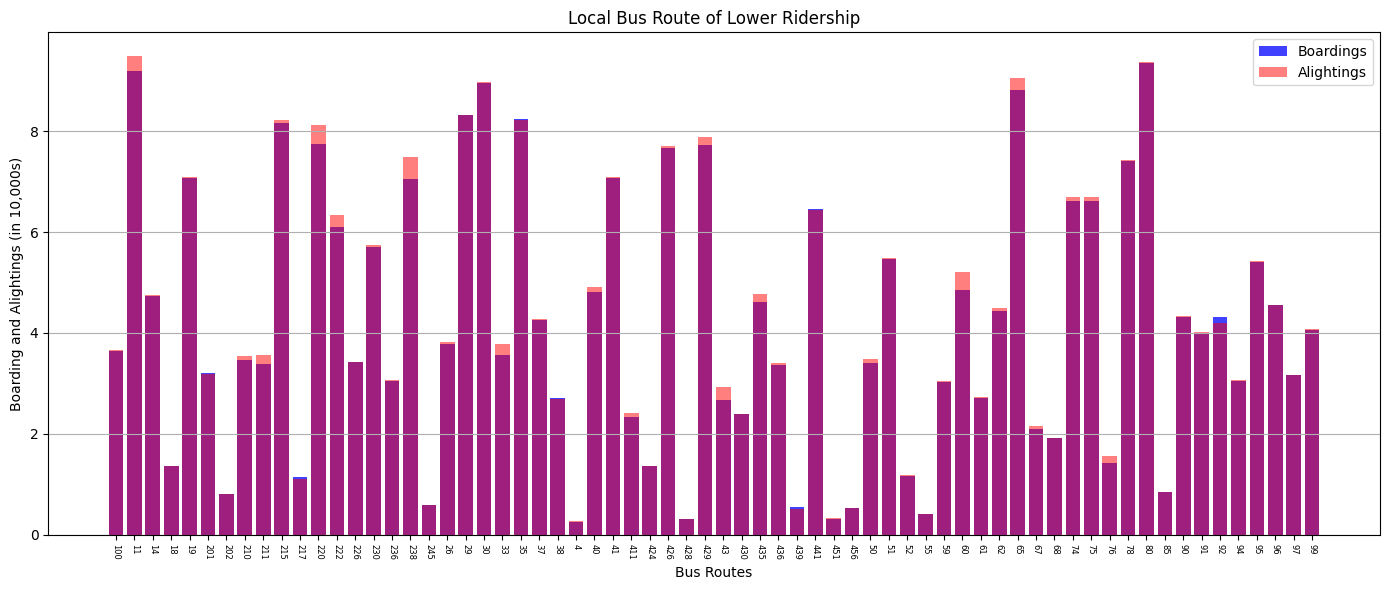

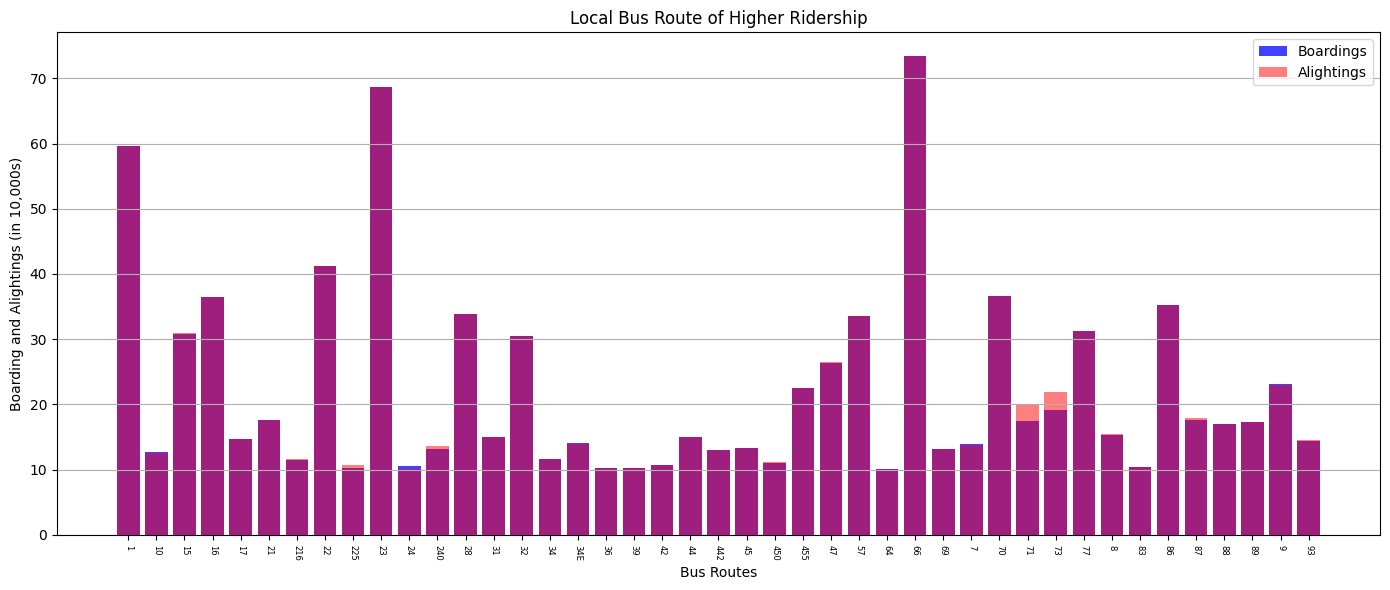

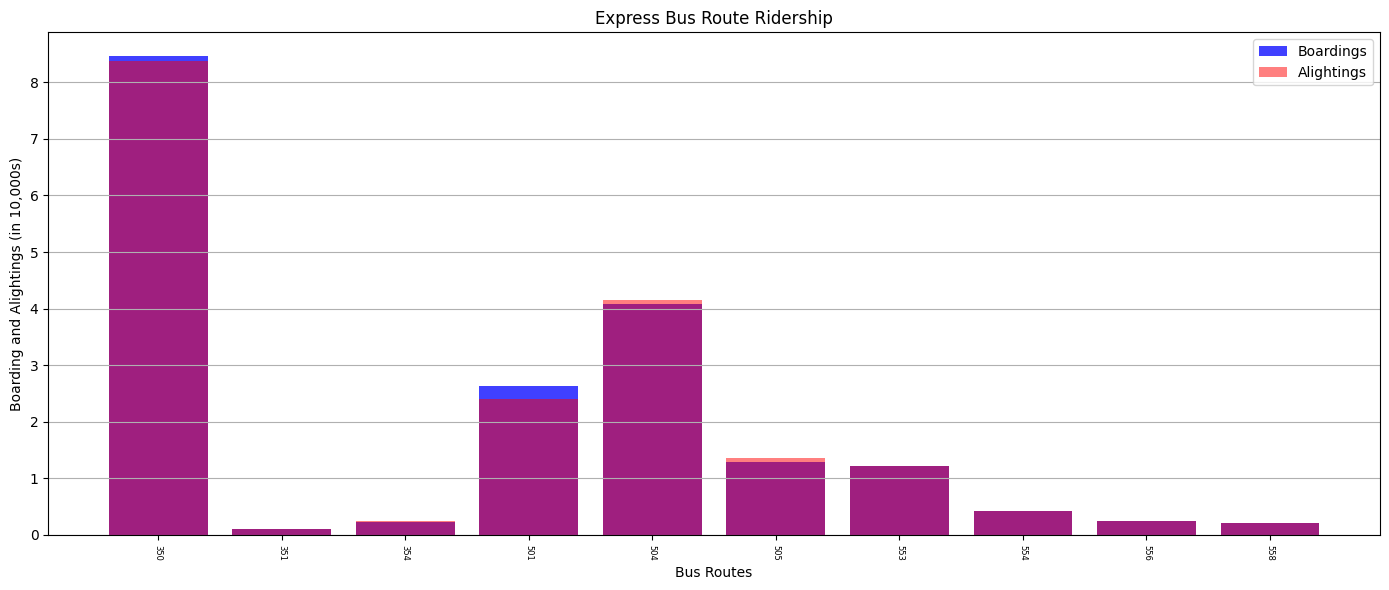

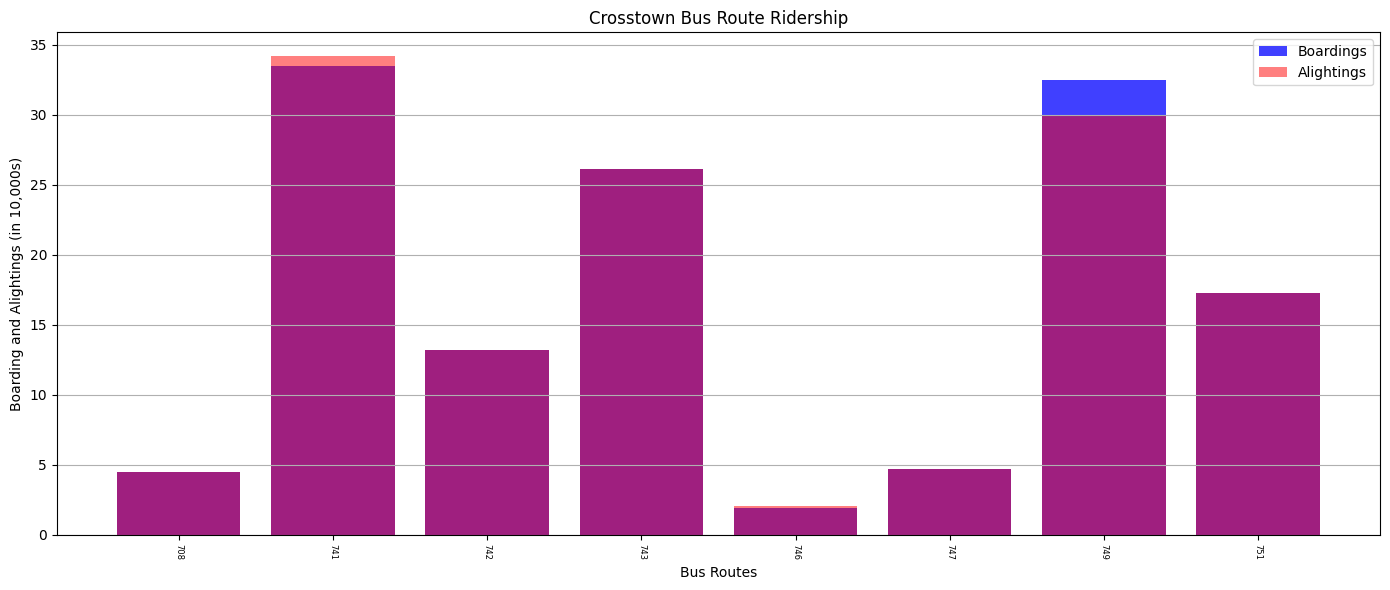

In [44]:
# Loads file
df = clean_ridership('MBTA_Bus_Ridership_Fall_2022.csv')

routes = np.unique(df['route_id'])

local_routes = []
express_routes = []
crosstown = []
limited_express_400s = [426, 428, 441, 442, 450, 455, 456]

for route in routes:
    # Convert to int if possible, otherwise keep it as a string for cases like '34E' or '70A'
    try:
        route_num = int(route)
    except ValueError:
        route_num = route  # Keep as is if not convertible

    if isinstance(route_num, int):
        if 1 <= route_num <= 100:
            local_routes.append(route)
        elif 200 <= route_num <= 299:
            local_routes.append(route)  # 200s considered local
        elif 300 <= route_num <= 399:
            express_routes.append(route)  # 300s considered express
        elif 400 <= route_num <= 499:
            if route in limited_express_400s:
                express_routes.append(route)  # Specific 400s as express
            else:
                local_routes.append(route) # Rest considered local
        elif 500 <= route_num <= 599:
            express_routes.append(route)
        elif 700 <= route_num <= 799:
            crosstown.append(route)
    else:
        # Include any other routes that are not numerical number
        if isinstance(route, str):
            local_routes.append(route)
            
local = df[df['route_id'].isin(local_routes)]
express = df[df['route_id'].isin(express_routes)]
ct = df[df['route_id'].isin(crosstown)]

#Calculates boardings and alightings by bus routes
local_ridership_by_stop = local.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
local_ridership_by_stop["difference"] = local_ridership_by_stop['total_boardings'] - local_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
express_ridership_by_stop = express.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
express_ridership_by_stop["difference"] = express_ridership_by_stop['total_boardings'] - express_ridership_by_stop['total_alightings']

#Calculates boardings and alightings by bus routes
ct_ridership_by_stop = ct.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
ct_ridership_by_stop["difference"] = ct_ridership_by_stop['total_boardings'] - ct_ridership_by_stop['total_alightings']

lower_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] <= 100000) | 
    (local_ridership_by_stop['total_alightings'] <= 100000)
]

higher_local_low_ridership = local_ridership_by_stop[
    (local_ridership_by_stop['total_boardings'] > 100000) & 
    (local_ridership_by_stop['total_alightings'] > 100000)
]

# Lower Local Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(lower_local_low_ridership.index.astype(str), lower_local_low_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(lower_local_low_ridership.index.astype(str), lower_local_low_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route of Lower Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')  # Grid lines only on the y-axis
plt.ylim(0, None)
plt.show()

# Higher Local Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(higher_local_low_ridership.index.astype(str), higher_local_low_ridership['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(higher_local_low_ridership.index.astype(str), higher_local_low_ridership['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Local Bus Route of Higher Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')  # Grid lines only on the y-axis
plt.ylim(0, None)
plt.show()

# Express Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(express_ridership_by_stop.index.astype(str), express_ridership_by_stop['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(express_ridership_by_stop.index.astype(str), express_ridership_by_stop['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Express Bus Route Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

# Crosstown Bus Route Ridership Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(ct_ridership_by_stop.index.astype(str), ct_ridership_by_stop['total_boardings'] / 10000, color='blue', alpha=0.75, label='Boardings')
plt.bar(ct_ridership_by_stop.index.astype(str), ct_ridership_by_stop['total_alightings'] / 10000, color='red', alpha=0.5, label='Alightings')
plt.title("Crosstown Bus Route Ridership")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(axis='y')
plt.ylim(0, None)
plt.show()

In [ ]:
#Calculates boardings and alightings by bus routes
ridership_by_stop = file.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
# Calculates the differences of ridership per bus routes
ridership_by_stop["difference"] = ridership_by_stop['total_boardings'] - ridership_by_stop['total_alightings']

# Create a copy of the original dataframe with the specific columns
copy_df = file[['route_id', 'trip_start_time', 'stop_name', 'total_boardings', 'total_alightings']].copy()
# Gets the index of the peak boarding and alightings using 'idxmax()'
peak_ridership_idx = copy_df.groupby('route_id')[['total_boardings', 'total_alightings']].idxmax()
# Use the index from 'peak_ridership_idx' to get the rows with peak ridership
# Extract the rows corresponding to peak boardings
peak_boardings = copy_df.loc[peak_ridership_idx['total_boardings'], ['route_id', 'trip_start_time', 'stop_name', 'total_boardings']]
# Extract the rows corresponding to peak alightings
peak_alightings = copy_apt
df.loc[peak_ridership_idx['total_alightings'], ['route_id', 'trip_start_time', 'stop_name', 'total_alightings']]

# Plot total boarding and alightings by bus routes
plt.figure(figsize=(14, 6)) # Extends figure size
plt.scatter(ridership_by_stop.index.astype(str), (ridership_by_stop['total_boardings'] / 10000), color = 'blue', s = 10, alpha = 0.75, label='Boardings') # Assigns scatterplot of bus route vs boarding as "blue"
plt.scatter(ridership_by_stop.index.astype(str), (ridership_by_stop['total_alightings'] / 10000), color = 'red', s = 10, alpha = 0.5, label='Alightings') # Assigns scatterplot of bus route vs alightings as "red"
plt.title("Ridership by Bus Route")
plt.xlabel("Bus Routes")
plt.ylabel("Boarding and Alightings (in 10,000s)")
plt.xticks(rotation=270, fontsize=6)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()